In [137]:
import pandas as pd
import numpy as np
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split 

In [138]:
df = pd.read_csv('/Users/lakshyapunjabi/Desktop/stress.csv')
df.head()


,self_esteem,mental_health_history,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,20,0,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,8,1,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,18,1,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,12,1,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,28,0,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


In [139]:
features=[x for x in df.columns if x!='stress_level']
print(len(features))


18


In [140]:
#splitting the data now
xtrain,xval,ytrain,yval=train_test_split(df[features],df['stress_level'],train_size=0.8,random_state=42)
xval,xtest,yval,ytest=train_test_split(xval,yval,train_size=0.5,random_state=42)
print(xtrain.shape,ytrain.shape)

(880, 18) (880,)


In [141]:
#making the model
model=XGBClassifier(max_depth=5,        # shallower trees
    n_estimators=100,   
    random_state=42,
    learning_rate=0.004,
     
                )
model.fit(xtrain,ytrain)
print(model.score(xtrain,ytrain))
print(model.score(xval,yval))

0.9693181818181819
0.8818181818181818


In [142]:
#predictions
y_pred = model.predict(xtest)
wrong = (y_pred != ytest)
print(f"Wrong predictions: {wrong.sum()} / {len(ytest)}")

Wrong predictions: 14 / 110


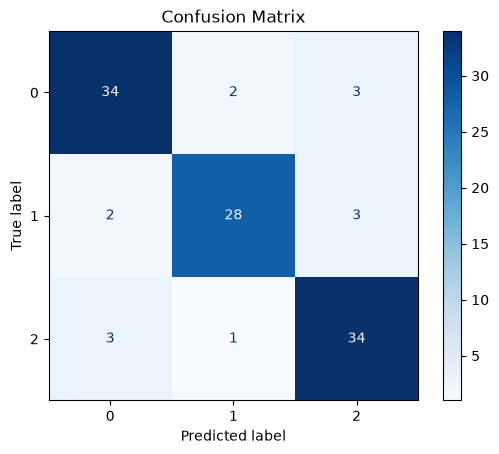

              precision    recall  f1-score   support

         Low       0.87      0.87      0.87        39
      Medium       0.90      0.85      0.88        33
        High       0.85      0.89      0.87        38

    accuracy                           0.87       110
   macro avg       0.88      0.87      0.87       110
weighted avg       0.87      0.87      0.87       110



In [143]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(xtest)

# Confusion matrix
cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Precision, recall, F1 per class
print(classification_report(ytest, y_pred, target_names=['Low', 'Medium', 'High']))